# 01 — Keşifsel Veri Analizi (EDA)

**Proje:** İkinci El SUV Fiyat Sınıflandırma (Nissan + Hyundai)  
**Veri:** `data/ARABAMVS.csv` — 3425 satır × 43 sütun  
**Hedef:** Fiyat'ı quartile'lara bölerek 4 sınıflı `Fiyat_Sinifi` türetmek (Ekonomik / Orta / Yüksek / Premium)

Bu notebook **sadece keşif ve görselleştirme** içerir. Encoding, scaling, missing-value doldurma `02_preprocessing.ipynb`'ye bırakılmıştır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## 1. Veri Yükleme ve İlk Bakış

In [2]:
df = pd.read_csv('../data/ARABAMVS.csv')
print(f'Satır: {df.shape[0]}, Sütun: {df.shape[1]}')
print(f'\nTip dağılımı:')
print(df.dtypes.value_counts().to_string())

Satır: 3425, Sütun: 43

Tip dağılımı:
float64    24
object     19


In [3]:
df.head()

,_Başlık,Fiyat,Marka,Seri,Model,Yıl,Kilometre,Vites Tipi,Yakıt Tipi,Kasa Tipi,...,Şehir İçi Yakıt Tüketimi,Şehir Dışı Yakıt Tüketimi,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Koltuk Sayısı,Bagaj Hacmi,Ön Lastik
0,Sahibinden Nissan Qashqai 13 DIG-T Sky Pack 20...,2425000.0,Nissan,Qashqai,13 DIG-T Sky Pack,2025.0,6001.0,2.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sahibinden Nissan Qashqai 13 DIG-T Platinum Pr...,2900000.0,Nissan,Qashqai,13 DIG-T Platinum Premium,2025.0,265000.0,2.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN
2,Galeriden Nissan Qashqai 15 dCi Platinum Premi...,1150000.0,Nissan,Qashqai,15 dCi Platinum Premium Pack,2015.0,196000.0,0.0,1.0,1.0,...,"4,2","3,6",4379.0,1800.0,1590.0,1910.0,1365,5.0,401.0,225/45
3,Sahibinden Nissan Qashqai 16 dCi Platinum Prem...,1240000.0,Nissan,Qashqai,16 dCi Platinum Premium Pack,2014.0,305000.0,2.0,1.0,1.0,...,"5,3","4,2",4379.0,1800.0,1590.0,2005.0,1461,5.0,401.0,215/60
4,Galeriden Nissan Qashqai 15 dCi Tekna 2011 Mod...,690000.0,Nissan,Qashqai,15 dCi Tekna,2011.0,43500.0,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3425 entries, 0 to 3424
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   _Başlık                    3424 non-null   object 
 1   Fiyat                      3424 non-null   float64
 2   Marka                      3424 non-null   object 
 3   Seri                       3424 non-null   object 
 4   Model                      3424 non-null   object 
 5   Yıl                        3424 non-null   float64
 6   Kilometre                  3422 non-null   float64
 7   Vites Tipi                 3424 non-null   float64
 8   Yakıt Tipi                 3424 non-null   float64
 9   Kasa Tipi                  3424 non-null   float64
 10  Renk                       3424 non-null   float64
 11  Motor Hacmi                3294 non-null   object 
 12  Motor Gücü                 3331 non-null   object 
 13  Çekiş                      1585 non-null   float

**Yorum:** 3425 ilan × 43 sütun. `Vites Tipi`, `Yakıt Tipi`, `Kasa Tipi`, `Renk`, `Kimden`, `Çekiş` zaten label-encoded (0/1/2 kodlu). `Motor Hacmi`, `Motor Gücü` gibi numerikler object tipinde — preprocessing'te parse edilecek.

## 2. Eksik Değer Analizi

In [5]:
eksik = pd.DataFrame({
    'Eksik Sayısı': df.isna().sum(),
    'Eksik %': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('Eksik %', ascending=False)
eksik[eksik['Eksik Sayısı'] > 0]

,Eksik Sayısı,Eksik %
Şanzıman,2170,63.36
Çekiş,1840,53.72
Ağırlık,1541,44.99
Ortalama Kasko,1310,38.25
Ortalama Trafik Sigortası,1295,37.81
Şehir İçi Yakıt Tüketimi,1260,36.79
Şehir Dışı Yakıt Tüketimi,1255,36.64
Maksimum Güç,1158,33.81
Minimum Güç,1158,33.81
Bagaj Hacmi,1139,33.26


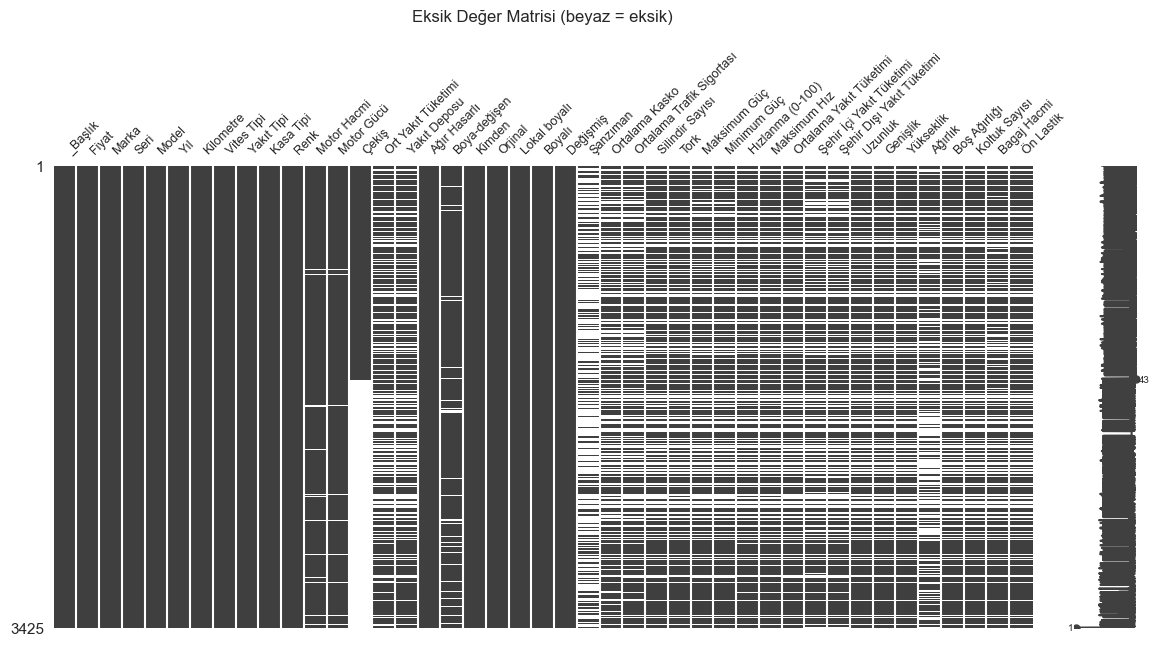

In [6]:
msno.matrix(df, figsize=(14, 6), fontsize=9)
plt.title('Eksik Değer Matrisi (beyaz = eksik)', pad=20)
plt.show()

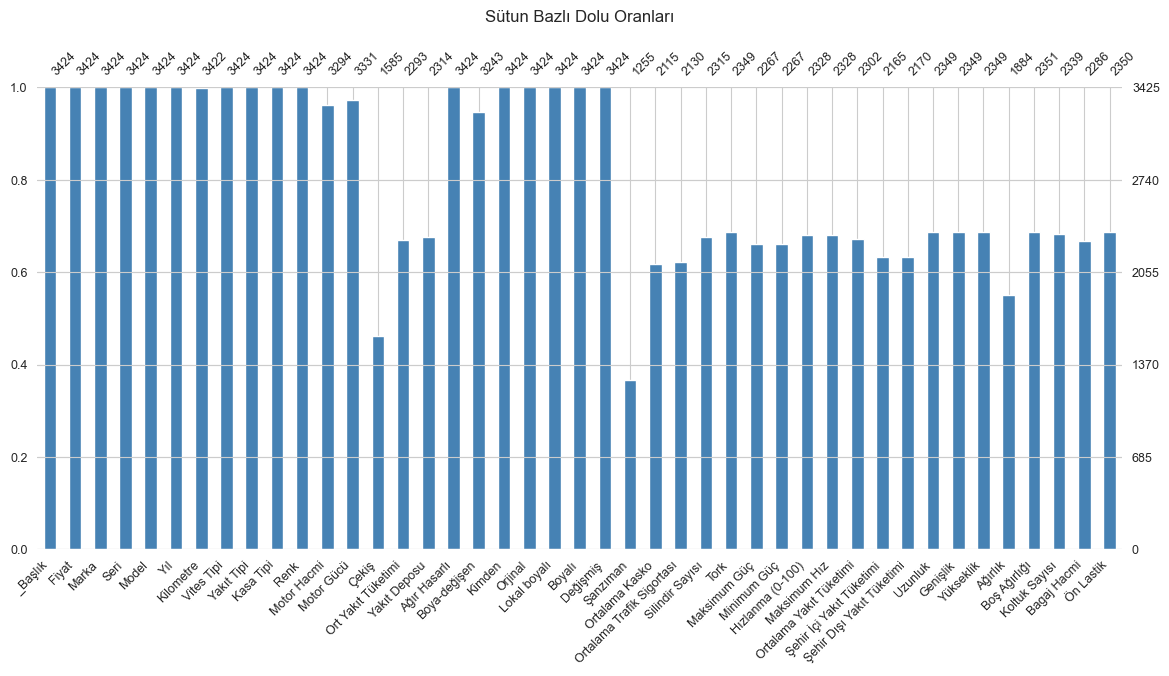

In [7]:
msno.bar(df, figsize=(14, 6), fontsize=9, color='steelblue')
plt.title('Sütun Bazlı Dolu Oranları', pad=20)
plt.show()

**Yorum — eksik değer stratejisi:**
- **%50+ eksik:** `Şanzıman` (%63), `Çekiş` (%54), `Ağırlık` (%45) → preprocessing'te atılacak veya özel ele alınacak
- **%30-45 eksik:** Yakıt tüketimi, motor güç, sigorta sütunları → grup medyanı ile doldurulabilir
- **%10 altı:** Basit medyan/mod yeterli
- `Fiyat`, `Marka`, `Yıl`, `Kilometre` neredeyse dolu — modelleme için iyi

## 3. Hedef Değişken (Fiyat) Analizi

In [8]:
df['Fiyat'] = pd.to_numeric(df['Fiyat'], errors='coerce')
print('Fiyat — özet istatistikler:')
print(df['Fiyat'].describe().apply(lambda x: f'{x:,.0f}'))

Fiyat — özet istatistikler:
count         3,424
mean      1,495,276
std         607,114
min         150,000
25%       1,100,000
50%       1,429,950
75%       1,799,850
max      15,000,000
Name: Fiyat, dtype: object


In [9]:
alt = df['Fiyat'].quantile(0.01)
ust = df['Fiyat'].quantile(0.99)
print(f'Alt %1 persentil : {alt:>12,.0f} TL')
print(f'Üst %1 persentil : {ust:>12,.0f} TL')
print(f'Alt %1 altında   : {(df["Fiyat"] < alt).sum()} ilan')
print(f'Üst %1 üstünde   : {(df["Fiyat"] > ust).sum()} ilan')

Alt %1 persentil :      445,632 TL
Üst %1 persentil :    2,950,000 TL
Alt %1 altında   : 35 ilan
Üst %1 üstünde   : 34 ilan


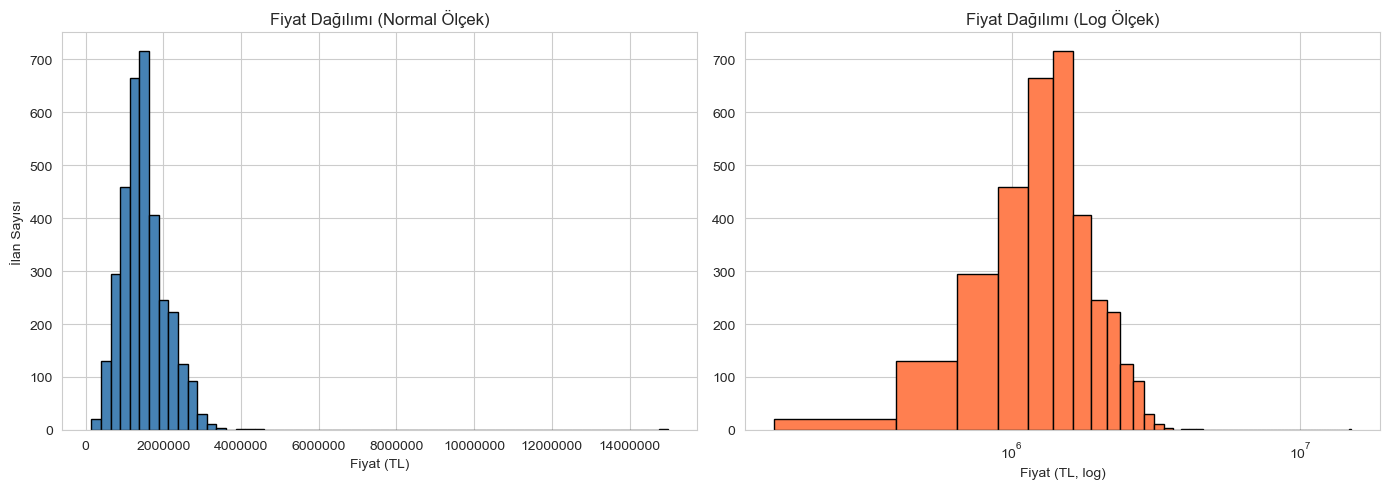

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Fiyat'].dropna(), bins=60, color='steelblue', edgecolor='black')
axes[0].set_title('Fiyat Dağılımı (Normal Ölçek)')
axes[0].set_xlabel('Fiyat (TL)')
axes[0].set_ylabel('İlan Sayısı')
axes[0].ticklabel_format(axis='x', style='plain')

axes[1].hist(df['Fiyat'].dropna(), bins=60, color='coral', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_title('Fiyat Dağılımı (Log Ölçek)')
axes[1].set_xlabel('Fiyat (TL, log)')
plt.tight_layout()
plt.show()

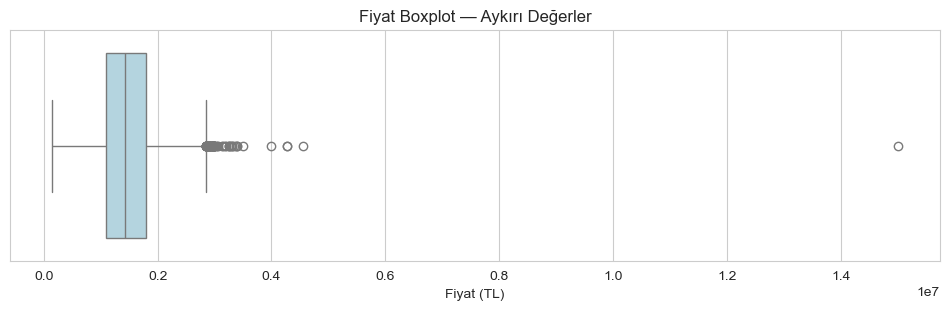

In [11]:
plt.figure(figsize=(12, 3))
sns.boxplot(x=df['Fiyat'], color='lightblue')
plt.title('Fiyat Boxplot — Aykırı Değerler')
plt.xlabel('Fiyat (TL)')
plt.show()

**Yorum:** Fiyat dağılımı **sağa çarpık**. Üst sınırın çok dışında birkaç ilan var (premium veya hatalı). Quartile bölünmesi rank-tabanlı olduğu için aykırılara dayanıklı — sınıflandırma için sorun olmaz. Ekstrem ilanlar preprocessing'te alt %1 / üst %1 ile gözden geçirilecek.

## 4. Numerik Sütun Analizi

In [12]:
# Object tipinde olup numerik olanları parse et (sadece EDA için, preprocessing'te asıl yapılacak)
object_to_num = ['Motor Hacmi', 'Motor Gücü', 'Tork', 'Maksimum Güç', 'Minimum Güç',
                 'Hızlanma (0-100)', 'Maksimum Hız', 'Uzunluk', 'Genişlik',
                 'Yükseklik', 'Boş Ağırlığı', 'Koltuk Sayısı', 'Bagaj Hacmi',
                 'Ortalama Kasko', 'Ortalama Trafik Sigortası',
                 'Ort Yakıt Tüketimi', 'Ortalama Yakıt Tüketimi',
                 'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi',
                 'Yakıt Deposu', 'Silindir Sayısı']
for col in object_to_num:
    if col in df.columns and df[col].dtype == object:
        df[col] = (df[col].astype(str)
                   .str.replace(',', '.', regex=False)
                   .str.extract(r'([-+]?\d*\.?\d+)')[0])
        df[col] = pd.to_numeric(df[col], errors='coerce')

numerik_sutunlar = df.select_dtypes(include=np.number).columns.tolist()
print(f'Numerik sütun sayısı: {len(numerik_sutunlar)}')

Numerik sütun sayısı: 32


In [13]:
ana_numerik = ['Fiyat', 'Yıl', 'Kilometre', 'Motor Hacmi', 'Motor Gücü',
               'Silindir Sayısı', 'Maksimum Hız', 'Bagaj Hacmi']
ana_numerik = [c for c in ana_numerik if c in df.columns]
df[ana_numerik].describe().round(1)

,Fiyat,Yıl,Kilometre,Motor Hacmi,Motor Gücü,Silindir Sayısı,Maksimum Hız,Bagaj Hacmi
count,3424.0,3424.0,3422.0,3286.0,3316.0,2315.0,2328.0,2286.0
mean,1495275.8,2017.8,122327.1,1529.2,134.4,3.9,179.0,468.5
std,607114.0,5.1,88565.1,275.0,27.5,0.3,10.8,116.0
min,150000.0,1996.0,3.0,998.0,51.0,3.0,135.0,115.0
25%,1100000.0,2015.0,52000.0,1461.0,115.0,4.0,175.0,401.0
50%,1429950.0,2018.0,107000.0,1500.0,135.0,4.0,180.0,411.0
75%,1799850.0,2022.0,171000.0,1598.0,140.0,4.0,182.0,550.0
max,15000000.0,2025.0,610000.0,3275.0,609.0,6.0,260.0,1180.0


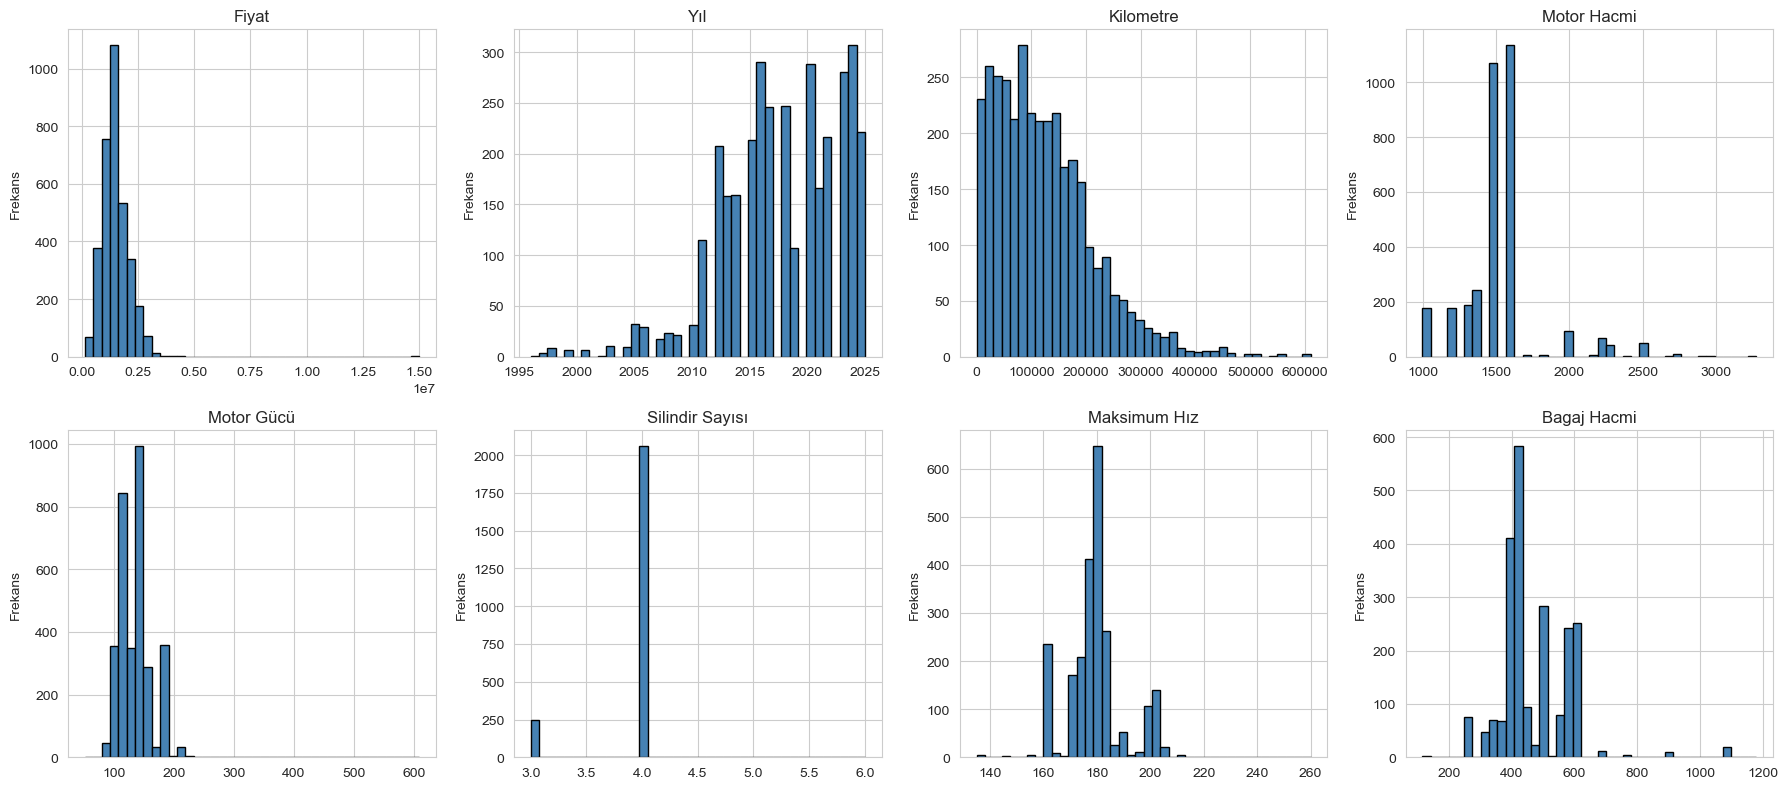

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), ana_numerik):
    seri = df[col].dropna()
    ax.hist(seri, bins=40, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_ylabel('Frekans')
plt.tight_layout()
plt.show()

**Yorum:** `Yıl` son yıllara doğru yoğun (yeni araçlar daha çok). `Kilometre` sağa çarpık. `Motor Hacmi` belirli tipik değerlerde kümeli (1.4L, 1.6L, 2.0L). `Silindir Sayısı` kesikli.

## 5. Kategorik Sütun Analizi

In [15]:
# Vites/Yakıt/Kasa/Renk/Kimden CSV'de label-encoded — kategori gibi inceliyoruz
kategorikler = ['Marka', 'Seri', 'Yakıt Tipi', 'Vites Tipi', 'Kasa Tipi',
                'Renk', 'Kimden', 'Çekiş']
kategorikler = [c for c in kategorikler if c in df.columns]
for c in kategorikler:
    print(f'\n--- {c} (benzersiz: {df[c].nunique()}) ---')
    print(df[c].value_counts(dropna=False).head(8))


--- Marka (benzersiz: 2) ---
Marka
Nissan     1740
Hyundai    1684
NaN           1
Name: count, dtype: int64

--- Seri (benzersiz: 18) ---
Seri
Qashqai    1083
Tucson      920
Bayon       351
Juke        288
ix35        219
X-Trail     174
Kona        138
Navara      120
Name: count, dtype: int64

--- Yakıt Tipi (benzersiz: 5) ---
Yakıt Tipi
1.0    1690
0.0    1327
2.0     248
3.0     114
4.0      45
NaN       1
Name: count, dtype: int64

--- Vites Tipi (benzersiz: 3) ---
Vites Tipi
2.0    1898
0.0     766
1.0     760
NaN       1
Name: count, dtype: int64

--- Kasa Tipi (benzersiz: 4) ---
Kasa Tipi
1.0    3255
2.0      90
0.0      62
3.0      17
NaN       1
Name: count, dtype: int64

--- Renk (benzersiz: 4) ---
Renk
0.0    1313
3.0    1192
2.0     519
1.0     400
NaN       1
Name: count, dtype: int64

--- Kimden (benzersiz: 2) ---
Kimden
1.0    2165
0.0    1259
NaN       1
Name: count, dtype: int64

--- Çekiş (benzersiz: 3) ---
Çekiş
NaN    1840
0.0    1356
2.0     142
1.0      87
Nam

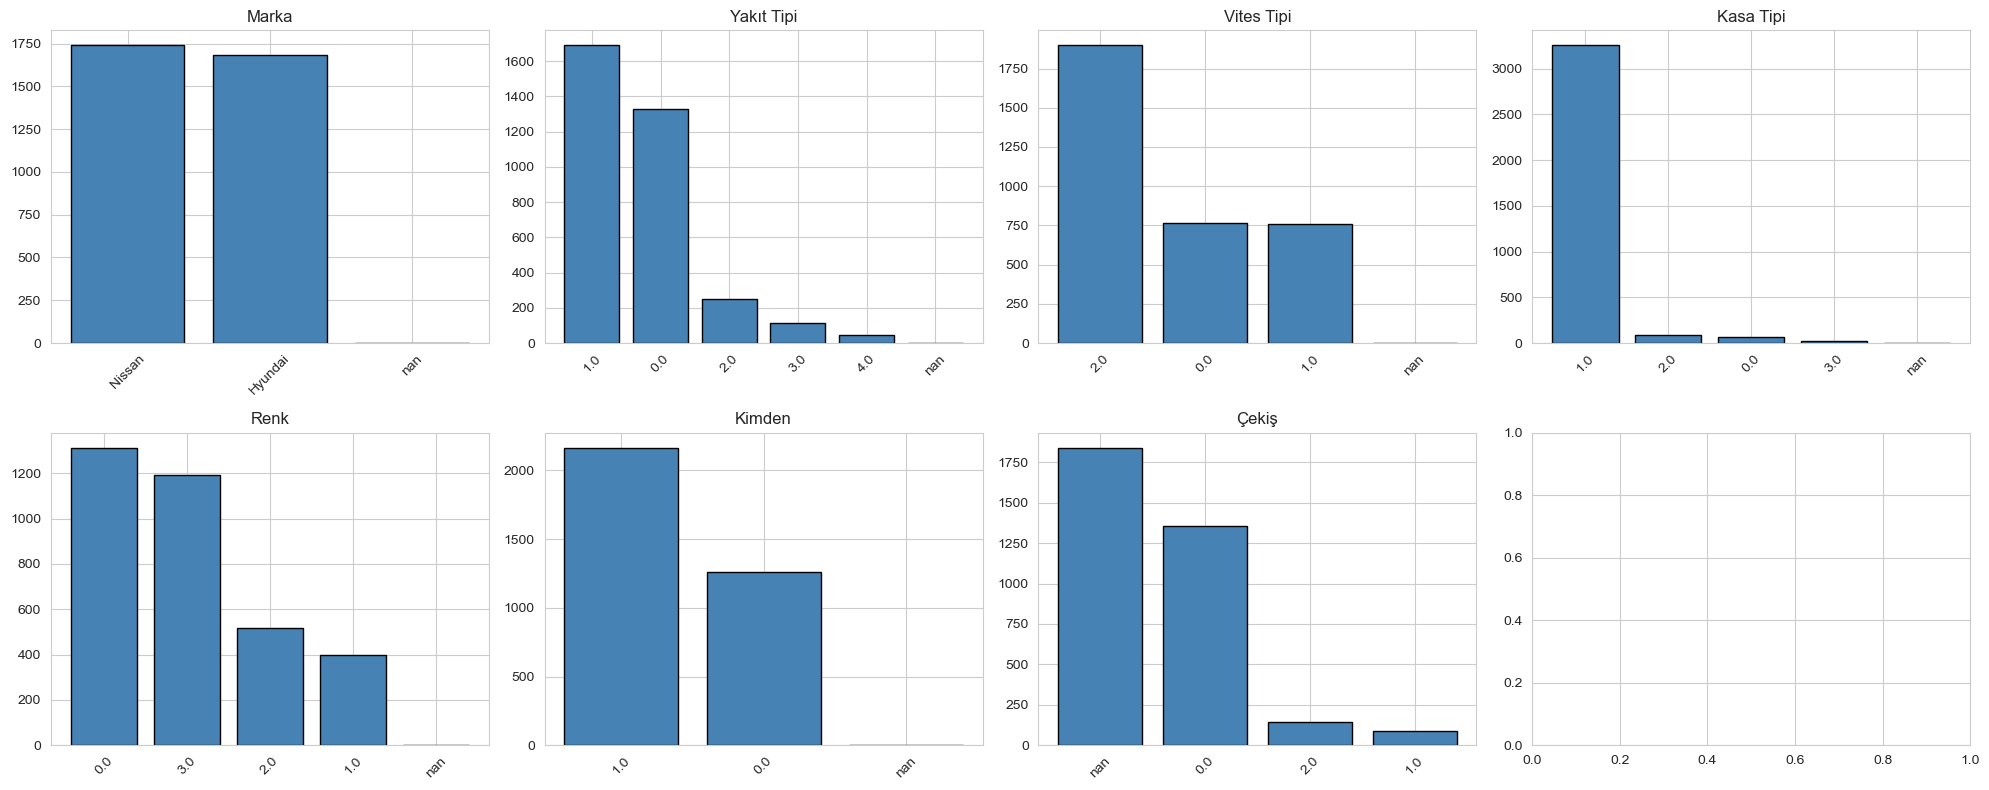

In [16]:
bar_kategori = [c for c in kategorikler if c != 'Seri']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), bar_kategori):
    vc = df[col].value_counts(dropna=False).head(10)
    ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Yorum:** `Marka` dengeli (Nissan ~1740, Hyundai ~1685). `Kasa Tipi` çok dengesiz — SUV (1.0) 3255 adet, diğerleri 1-90 arası. Bu dengesizlik preprocessing'te ele alınacak.

## 6. Korelasyon Analizi

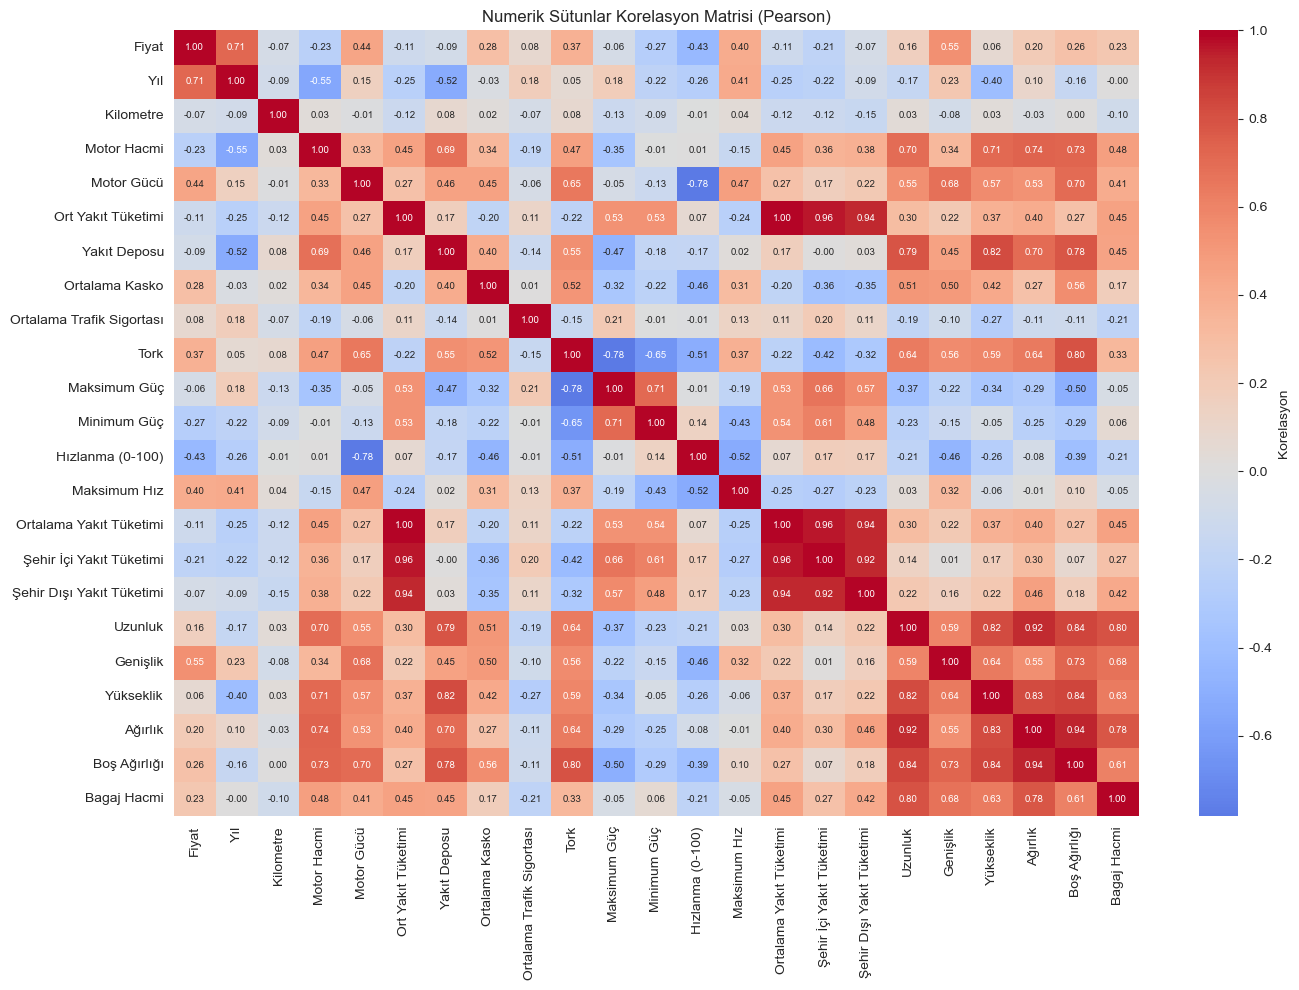

In [17]:
korel_sutunlar = [c for c in numerik_sutunlar
                  if df[c].nunique() > 5 and df[c].notna().sum() > 200]
corr = df[korel_sutunlar].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Korelasyon'}, annot_kws={'size': 7})
plt.title('Numerik Sütunlar Korelasyon Matrisi (Pearson)')
plt.tight_layout()
plt.show()

In [18]:
fiyat_kor = corr['Fiyat'].drop('Fiyat').abs().sort_values(ascending=False).head(10)
print('Fiyat ile en yüksek mutlak korelasyonlu 10 özellik:\n')
for ad, _ in fiyat_kor.items():
    print(f'  {ad:<32} {corr.loc[ad, "Fiyat"]:+.3f}')

Fiyat ile en yüksek mutlak korelasyonlu 10 özellik:

  Yıl                              +0.715
  Genişlik                         +0.547
  Motor Gücü                       +0.437
  Hızlanma (0-100)                 -0.430
  Maksimum Hız                     +0.404
  Tork                             +0.369
  Ortalama Kasko                   +0.285
  Minimum Güç                      -0.266
  Boş Ağırlığı                     +0.265
  Motor Hacmi                      -0.234


**Yorum:** Fiyat ile en güçlü ilişki: `Yıl` (+), `Kilometre` (-), `Motor Gücü/Hacmi` (+). `Motor Hacmi ↔ Silindir Sayısı`, yakıt tüketimi sütunları kendi aralarında yüksek korelasyonlu — modellemede çoklu doğrusallıktan kaçınmak gerekecek.

## 7. Hedef Sınıf Önizleme

In [19]:
siniflar = ['Ekonomik', 'Orta', 'Yüksek', 'Premium']
df['_Fiyat_Sinifi'] = pd.qcut(df['Fiyat'], q=4, labels=siniflar)
dagilim = df['_Fiyat_Sinifi'].value_counts().reindex(siniflar)
print('Sınıf dağılımı:\n')
for s, n in dagilim.items():
    print(f'  {s:<10} {n:>5} ilan ({n/len(df)*100:.1f}%)')

Sınıf dağılımı:

  Ekonomik     865 ilan (25.3%)
  Orta         847 ilan (24.7%)
  Yüksek       857 ilan (25.0%)
  Premium      855 ilan (25.0%)


In [20]:
print('Sınıf bazında fiyat aralıkları:\n')
for sinif in siniflar:
    mask = df['_Fiyat_Sinifi'] == sinif
    alt, ust = df.loc[mask, 'Fiyat'].min(), df.loc[mask, 'Fiyat'].max()
    print(f'  {sinif:<10} {alt:>12,.0f}  —  {ust:>12,.0f} TL')

Sınıf bazında fiyat aralıkları:

  Ekonomik        150,000  —     1,100,000 TL
  Orta          1,105,000  —     1,429,900 TL
  Yüksek        1,430,000  —     1,799,850 TL
  Premium       1,800,000  —    15,000,000 TL


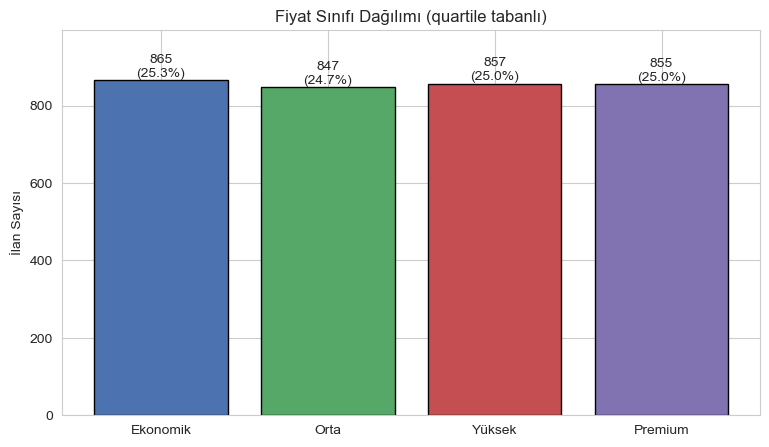

In [21]:
renkler = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
plt.figure(figsize=(9, 5))
bars = plt.bar(dagilim.index, dagilim.values, color=renkler, edgecolor='black')
for bar, n in zip(bars, dagilim.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{n}\n({n/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.title('Fiyat Sınıfı Dağılımı (quartile tabanlı)')
plt.ylabel('İlan Sayısı')
plt.ylim(0, max(dagilim.values) * 1.15)
plt.show()

**Yorum:** `pd.qcut` doğası gereği sınıflar yaklaşık eşit (~%25 her biri) — **dengeli sınıflar**, SMOTE gerekmez.

## 8. İki Değişkenli İlişki Analizi

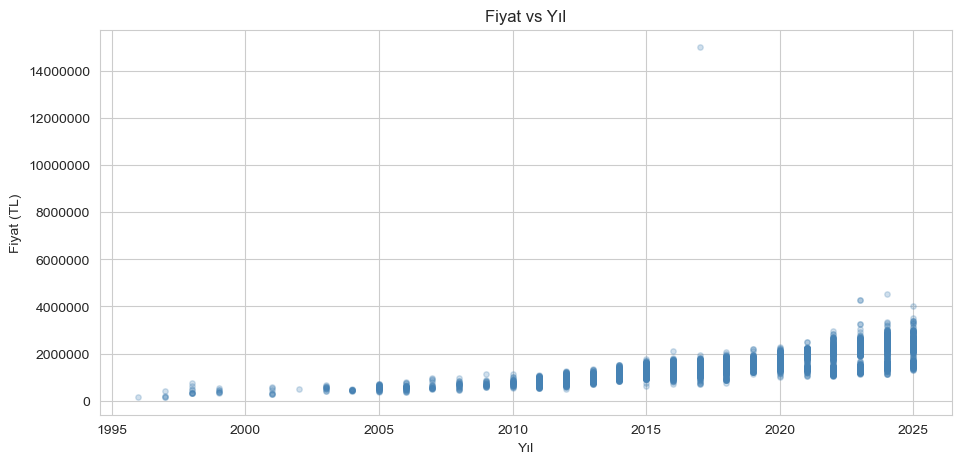

In [22]:
plt.figure(figsize=(11, 5))
plt.scatter(df['Yıl'], df['Fiyat'], alpha=0.25, s=15, color='steelblue')
plt.title('Fiyat vs Yıl')
plt.xlabel('Yıl'); plt.ylabel('Fiyat (TL)')
plt.ticklabel_format(axis='y', style='plain')
plt.show()

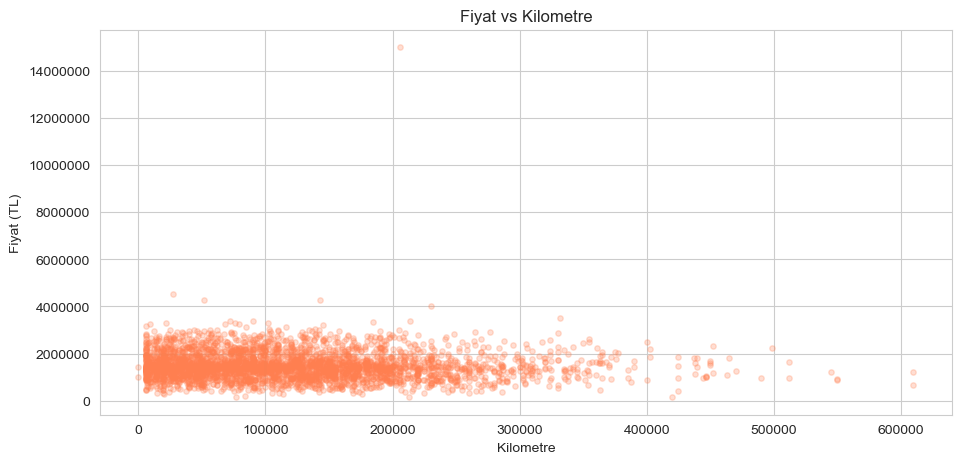

In [23]:
plt.figure(figsize=(11, 5))
plt.scatter(df['Kilometre'], df['Fiyat'], alpha=0.25, s=15, color='coral')
plt.title('Fiyat vs Kilometre')
plt.xlabel('Kilometre'); plt.ylabel('Fiyat (TL)')
plt.ticklabel_format(axis='both', style='plain')
plt.show()

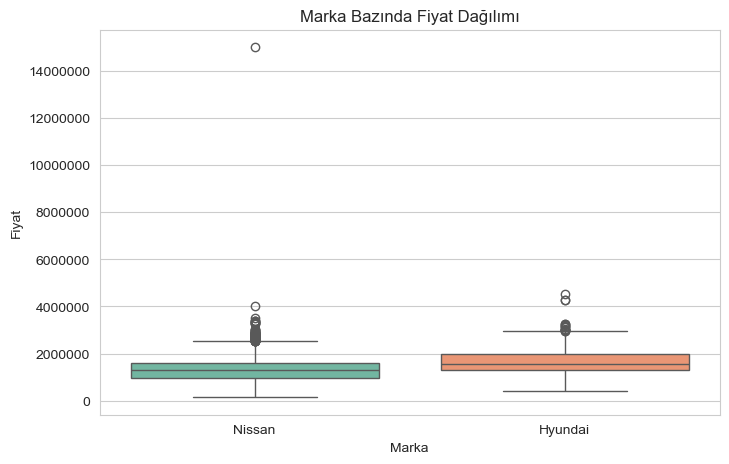

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Marka', y='Fiyat', palette='Set2')
plt.title('Marka Bazında Fiyat Dağılımı')
plt.ticklabel_format(axis='y', style='plain')
plt.show()

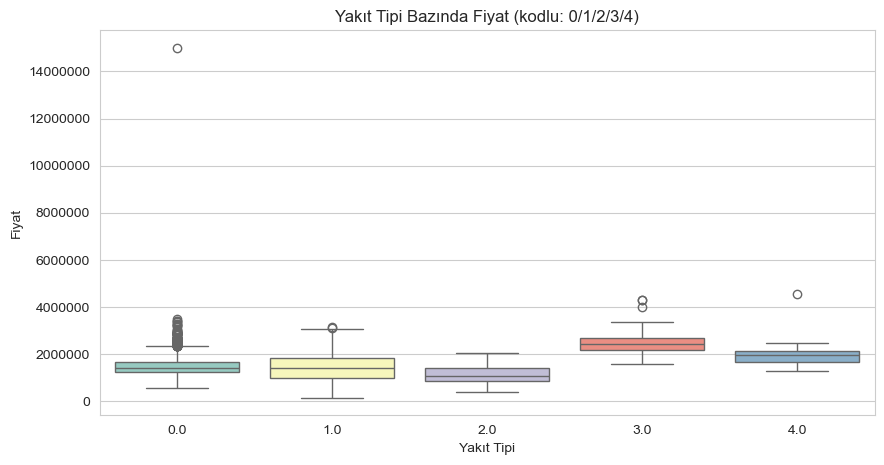

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Yakıt Tipi', y='Fiyat', palette='Set3')
plt.title('Yakıt Tipi Bazında Fiyat (kodlu: 0/1/2/3/4)')
plt.ticklabel_format(axis='y', style='plain')
plt.show()

**Yorum:** Yıl ↔ Fiyat güçlü pozitif. Kilometre ↔ Fiyat negatif (beklenen). Markalar arası medyan yakın ama yayılım farklı. Yakıt tipi kodları arasında belirgin fiyat farkı var (elektrikli/hibrit pahalı).

## 9. Sonuç ve Temizlik Tavsiyeleri

### Sütun atma
- **%50+ eksik:** `Şanzıman`, `Çekiş` (özel ele alınabilir), `Ağırlık`, `Ağır Hasarlı` → preprocessing'te at
- **`_Başlık`:** leakage riski + redundans → at
- **`Orjinal`:** uzun parça listesi metni → parça sayısına dönüştür

### Aykırı değer
- `Fiyat`: alt %1 / üst %1 winsorize gözden geçirilecek
- `Ortalama Kasko`: tek aykırı (72K Kona) muhtemelen hatalı

### Kategori birleştirme
- `Kasa Tipi`: SUV dışı az örnek → değerlendir
- `Seri`, `Model`: çok kategorili → target/frequency encoding

### Hedef değişken
- `pd.qcut` ile 4 sınıf → ~%25 dengeli
- Sınıflar: **Ekonomik / Orta / Yüksek / Premium**

---

### Sıradaki: `02_preprocessing.ipynb`
1. Yüksek-eksik sütunları at
2. Eksiklik desen analizi
3. Numerik string parse + `_Başlık` drop
4. Hedef oluştur (`Fiyat_Sinifi`)
5. Train/test split (stratify)
6. Eksik doldurma (train-fit)
7. Winsorize (`Ortalama Kasko`)
8. Encoding + Feature Engineering
9. Scaling (RobustScaler)
10. Final kayıt

In [26]:
df = df.drop(columns=['_Fiyat_Sinifi'])
print(f'EDA tamamlandı. Veri şekli: {df.shape}')

EDA tamamlandı. Veri şekli: (3425, 43)
